In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
RK4_hi_ac = pd.read_parquet("data/run_02_data_005_RK4_0.0100_15s.parquet")
RK4_lo_ac = pd.read_parquet('data/run_02_data_003_RK4_0.0500_15s.parquet')
Euler_hi_ac = pd.read_parquet("data/run_02_data_017_Euler_0.0100_15s.parquet")
Euler_lo_ac = pd.read_parquet("data/run_02_data_015_Euler_0.0500_15s.parquet")

In [3]:
t_hi_ac = []
for i in range(1500):
    t_hi_ac.append(i*0.01)

t_lo_ac = []
for i in range(300):
    t_lo_ac.append(i*0.05)

In [4]:
RK4_hi = RK4_hi_ac["energy"]
RK4_lo = RK4_lo_ac["energy"]

Euler_hi = Euler_hi_ac["energy"]
Euler_lo = Euler_lo_ac["energy"]

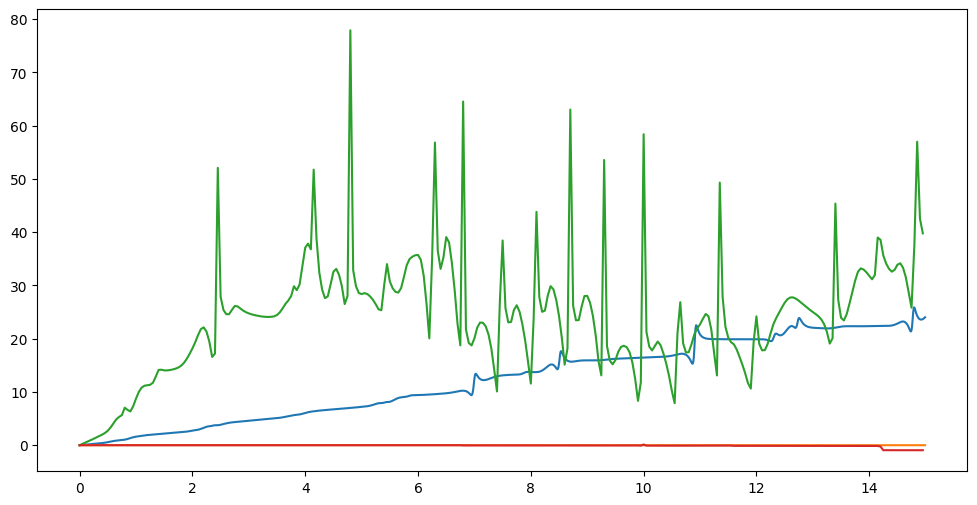

In [12]:
plt.figure(figsize = (12, 6))
plt.plot(t_hi_ac, Euler_hi)
plt.plot(t_hi_ac, RK4_hi)
plt.plot(t_lo_ac, Euler_lo)
plt.plot(t_lo_ac, RK4_lo)

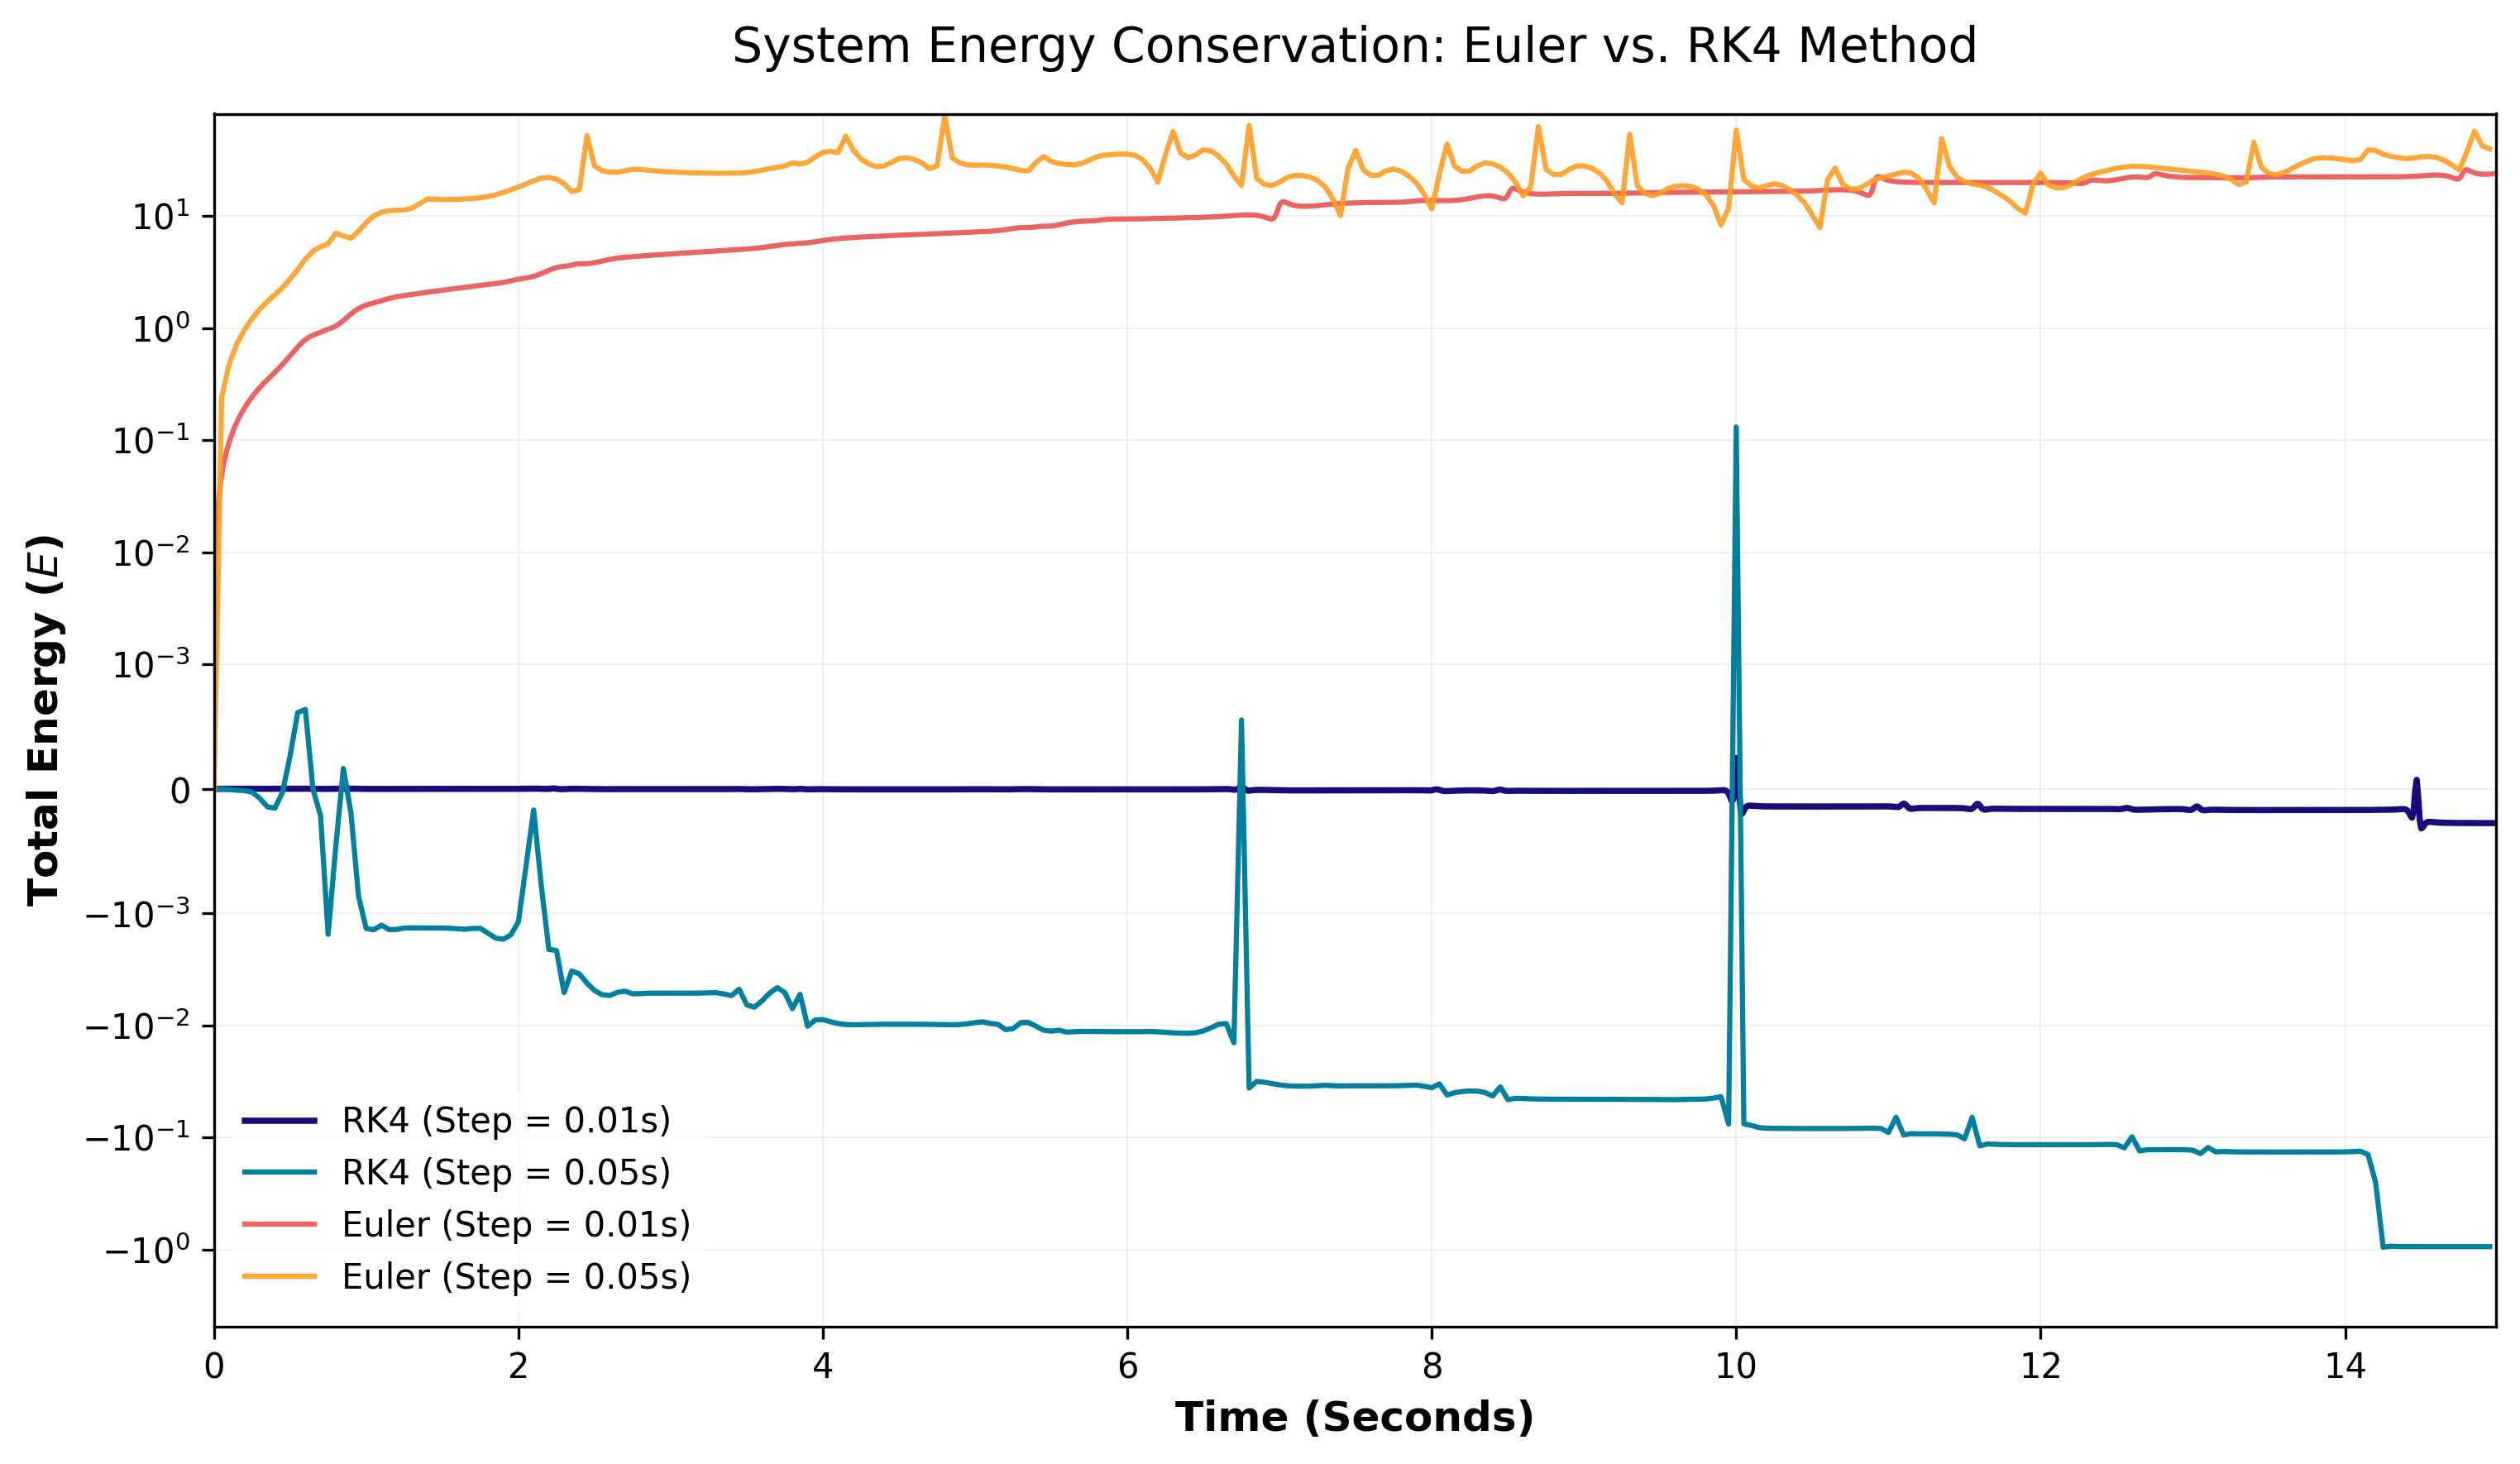

In [23]:
import matplotlib.pyplot as plt

# ============================================================
# 1. 初始化画布与风格设定
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# 定义高级感配色
# 深蓝/浅蓝代表优秀的 RK4，深红/浅橙代表容易发散的 Euler
color_rk4_hi = "#170C79"    # 经典深蓝
color_rk4_lo = "#00809D"    # 浅蓝
color_euler_hi = "#EA5252"  # 深红
color_euler_lo = "#FF9D23"  # 浅橙

# ============================================================
# 2. 绘制曲线（区分线型与粗细）
# 实线 (ls='-') 代表高精度/小步长，虚线 (ls='--') 代表低精度/大步长
# ============================================================
# RK4 组
ax.plot(t_hi_ac, RK4_hi, color=color_rk4_hi, ls='-', lw=1.8, 
        label="RK4 (Step = 0.01s)")
ax.plot(t_lo_ac, RK4_lo, color=color_rk4_lo, ls='-', lw=1.5, 
        label="RK4 (Step = 0.05s)")

# Euler 组
ax.plot(t_hi_ac, Euler_hi, color=color_euler_hi, ls='-', lw=1.5, alpha=0.9, 
        label="Euler (Step = 0.01s)")
ax.plot(t_lo_ac, Euler_lo, color=color_euler_lo, ls='-', lw=1.5, alpha=0.9, 
        label="Euler (Step = 0.05s)")

# ============================================================
# 3. 轴标签、图例与背景美化
# ============================================================
# 标题与标签
ax.set_title("System Energy Conservation: Euler vs. RK4 Method", fontsize=14, pad=15)
ax.set_xlabel("Time (Seconds)", fontsize=12, fontweight="bold")
ax.set_ylabel("Total Energy ($E$)", fontsize=12, fontweight="bold")

# 限制 X 轴范围紧贴数据边缘，防止两边留白过多
ax.set_xlim(min(min(t_hi_ac), min(t_lo_ac)), max(max(t_hi_ac), max(t_lo_ac)))

# 开启淡灰色细网格，保持学术图表的严谨与干净
ax.grid(True, which='both', linestyle='-', linewidth=0.4, color='#E5E5E5', alpha=0.7)

# 图例美化：去掉刺眼的黑色边框，微调位置
ax.legend(loc="best", frameon=True, facecolor="white", edgecolor="none", fontsize=10)

# 自动调整布局，防止标签被切掉
plt.tight_layout()
ax.set_yscale('symlog', linthresh=1e-3)

# ============================================================
# 4. 保存与展示
# ============================================================
plt.savefig("energy_conservation_comparison.png", dpi=600, bbox_inches="tight")
plt.savefig("energy_conservation_comparison.pdf", bbox_inches = 'tight')
plt.show()

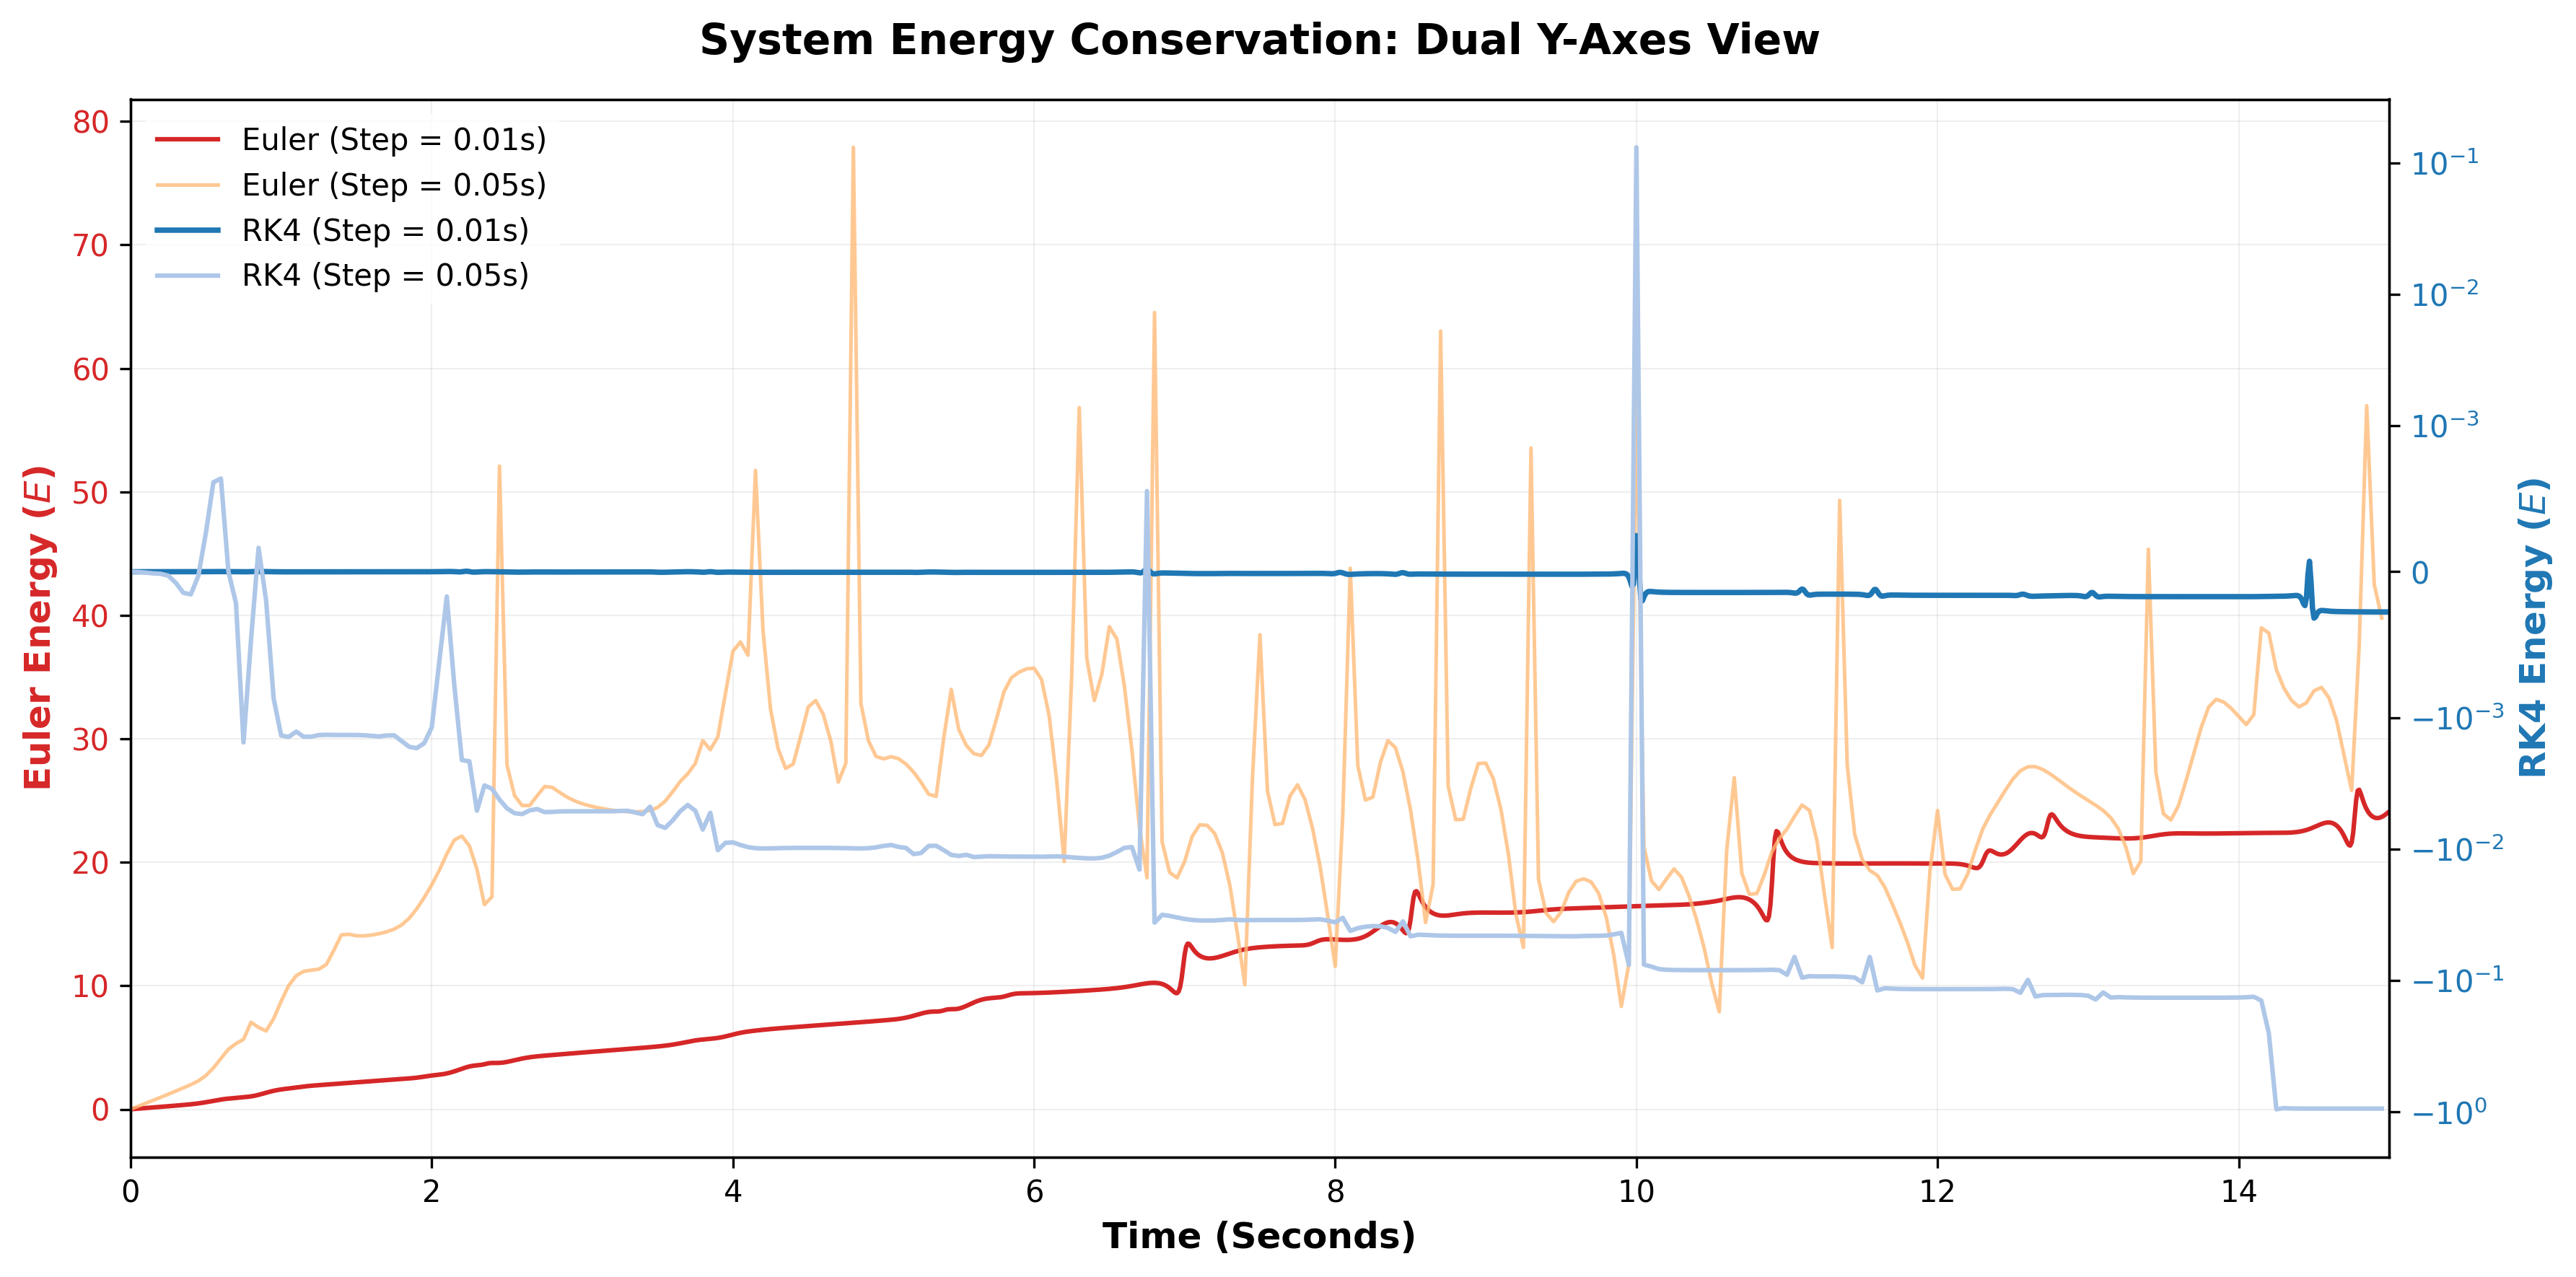

In [19]:
import matplotlib.pyplot as plt

# ============================================================
# 1. 创建画布与第一条 Y 轴 (ax1) —— 给 Euler 使用
# ============================================================
fig, ax1 = plt.subplots(figsize=(12, 6), dpi=300)

color_euler_hi = "#D62728"  # 深红
color_euler_lo = "#FFBB78"  # 浅橙

# 在 ax1 上绘制 Euler 法的数据（线性轴）
line1 = ax1.plot(t_hi_ac, Euler_hi, color=color_euler_hi, ls='-', lw=1.5, 
                 label="Euler (Step = 0.01s)")
line2 = ax1.plot(t_lo_ac, Euler_lo, color=color_euler_lo, ls='-', lw=1.2, alpha=0.8, 
                 label="Euler (Step = 0.05s)")

# 美化左侧 ax1
ax1.set_xlabel("Time (Seconds)", fontsize=12, fontweight="bold")
ax1.set_ylabel("Euler Energy ($E$)", fontsize=12, fontweight="bold", color=color_euler_hi)
ax1.tick_params(axis='y', labelcolor=color_euler_hi) # 让左边轴刻度颜色与曲线一致
ax1.grid(True, alpha=0.2, lw=0.5)

# ============================================================
# 2. 创建第二条 Y 轴 (ax2) 并共享 X 轴 —— 给 RK4 使用
# ============================================================
ax2 = ax1.twinx()

color_rk4_hi = "#1F77B4"    # 经典深蓝
color_rk4_lo = "#AEC7E8"    # 浅蓝

# 在 ax2 上绘制 RK4 法的数据
line3 = ax2.plot(t_hi_ac, RK4_hi, color=color_rk4_hi, ls='-', lw=1.8, 
                 label="RK4 (Step = 0.01s)")
line4 = ax2.plot(t_lo_ac, RK4_lo, color=color_rk4_lo, ls='-', lw=1.5, 
                 label="RK4 (Step = 0.05s)")

# 美化右侧 ax2（因为要看微观细节，强烈建议右边轴单独用 symlog 或 log）
ax2.set_ylabel("RK4 Energy ($E$)", fontsize=12, fontweight="bold", color=color_rk4_hi)
ax2.tick_params(axis='y', labelcolor=color_rk4_hi) # 让右边轴刻度颜色与曲线一致
ax2.set_yscale('symlog', linthresh=1e-3) # 右边单独开对数，绝配！

# ============================================================
# 3. 合并图例 (因为分属两个轴，需要手动合并图例标签)
# ============================================================
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left", frameon=True, facecolor="white", edgecolor="none")

# 限制 X 轴范围
ax1.set_xlim(0, 15)
plt.title("System Energy Conservation: Dual Y-Axes View", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()